In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
import plotly.express as px
import nbformat
print(nbformat.__version__)

5.10.4


In [4]:
import plotly.graph_objects as go

In [5]:
fvolume = pd.read_csv("Traffic_and_Capacity2.csv") 

In [28]:
fvolume.head()

,Year,Departures_count,Passenger_Enplane,RPM,ASM,Load Factor,Cargo RTM
0,2025,10189,971929,"1,134,868,536","1,383,991,247",82.00%,"48,540"
1,2024,9998,982710,"1,129,393,431","1,354,051,350",83.40%,"49,251"
2,2023,9635,941558,"1,077,928,526","1,293,177,405",83.40%,"48,103"
3,2022,9216,852508,"947,937,434","1,141,229,527",83.10%,"51,120"
4,2021,8366,666157,"687,919,477","932,947,801",73.70%,"52,516"


In [7]:
#fvolume.index[0:3]
fvolume = fvolume.loc[0:10]

In [32]:
fvolume_3 = fvolume.loc[0:3]

In [36]:
fvolume_1 = fvolume.loc[7:10]

In [40]:
fvolume_2 = fvolume.loc[4:6]

In [41]:
fvolume_2.head()

,Year,Departures_count,Passenger_Enplane,RPM,ASM,Load Factor,Cargo RTM
4,2021,8366,666157,"687,919,477","932,947,801",73.70%,"52,516"
5,2020,6468,369404,"378,016,195","643,203,246",58.80%,"46,429"
6,2019,10405,926745,"1,055,592,498","1,247,054,229",84.60%,"43,474"


In [33]:
fvolume_3.head()

,Year,Departures_count,Passenger_Enplane,RPM,ASM,Load Factor,Cargo RTM
0,2025,10189,971929,"1,134,868,536","1,383,991,247",82.00%,"48,540"
1,2024,9998,982710,"1,129,393,431","1,354,051,350",83.40%,"49,251"
2,2023,9635,941558,"1,077,928,526","1,293,177,405",83.40%,"48,103"
3,2022,9216,852508,"947,937,434","1,141,229,527",83.10%,"51,120"


In [8]:
print(fvolume['Departures_count'].head(9))
print(fvolume['Departures_count'].unique()[:9])

0    10,189
1     9,998
2     9,635
3     9,216
4     8,366
5     6,468
6    10,405
7    10,171
8     9,899
Name: Departures_count, dtype: object
['10,189' '9,998' '9,635' '9,216' '8,366' '6,468' '10,405' '10,171'
 '9,899']


In [9]:
fvolume.columns = fvolume.columns.str.strip()

In [10]:
fvolume['Departures_count'] = (
    fvolume['Departures_count']
    .astype(str)
    .str.strip()
    .str.replace(',', '')      # remove thousand separators
    .str.replace('..', '')     # remove weird missing markers
    .str.replace('-', '')      # remove dashes if used as missing
)

In [11]:
fvolume['Passenger_Enplane'] = (
    fvolume['Passenger_Enplane']
    .astype(str)
    .str.strip()
    .str.replace(',', '')      # remove thousand separators
    .str.replace('..', '')     # remove weird missing markers
    .str.replace('-', '')      # remove dashes if used as missing
)

In [12]:
fvolume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               11 non-null     int64 
 1   Departures_count   11 non-null     object
 2   Passenger_Enplane  11 non-null     object
 3   RPM                11 non-null     object
 4   ASM                11 non-null     object
 5   Load Factor        11 non-null     object
 6   Cargo RTM          11 non-null     object
dtypes: int64(1), object(6)
memory usage: 748.0+ bytes


In [13]:

# Convert departure count
fvolume['Departures_count'] = pd.to_numeric(
    fvolume['Departures_count'],
    errors='coerce'
)



In [14]:
#Convert Passenger_Enplane
fvolume['Passenger_Enplane'] = pd.to_numeric(
    fvolume['Passenger_Enplane'],
    errors='coerce'
)

In [15]:
fvolume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               11 non-null     int64 
 1   Departures_count   11 non-null     int64 
 2   Passenger_Enplane  11 non-null     int64 
 3   RPM                11 non-null     object
 4   ASM                11 non-null     object
 5   Load Factor        11 non-null     object
 6   Cargo RTM          11 non-null     object
dtypes: int64(3), object(4)
memory usage: 748.0+ bytes


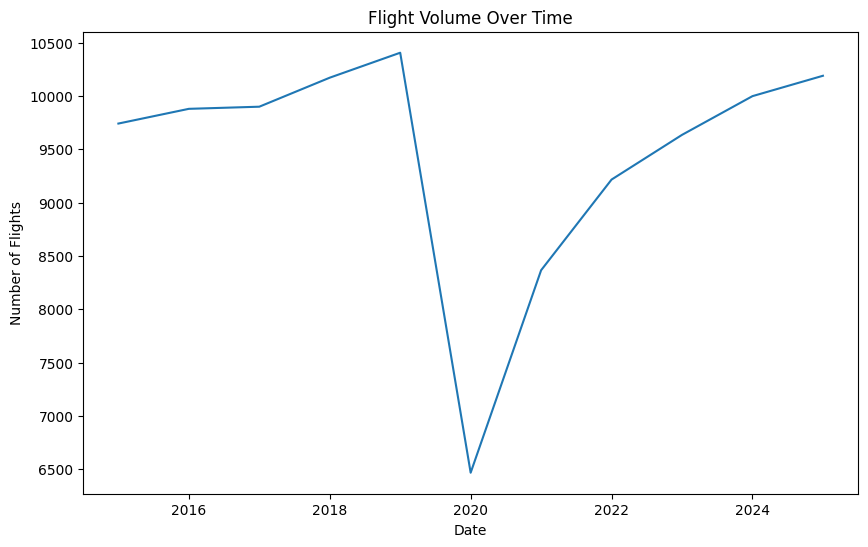

In [16]:
#top_customers = df.groupby('Customer Name')['Sales'].sum().nlargest(10).sort_values(ascending=True)

plt.figure(figsize=(10,6))
#plt.plot(flight_volume.index, flight_volume.values)
plt.plot(fvolume['Year'], fvolume['Departures_count'])#.sort_values(ascending=True)

plt.title("Flight Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Flights")

plt.show()

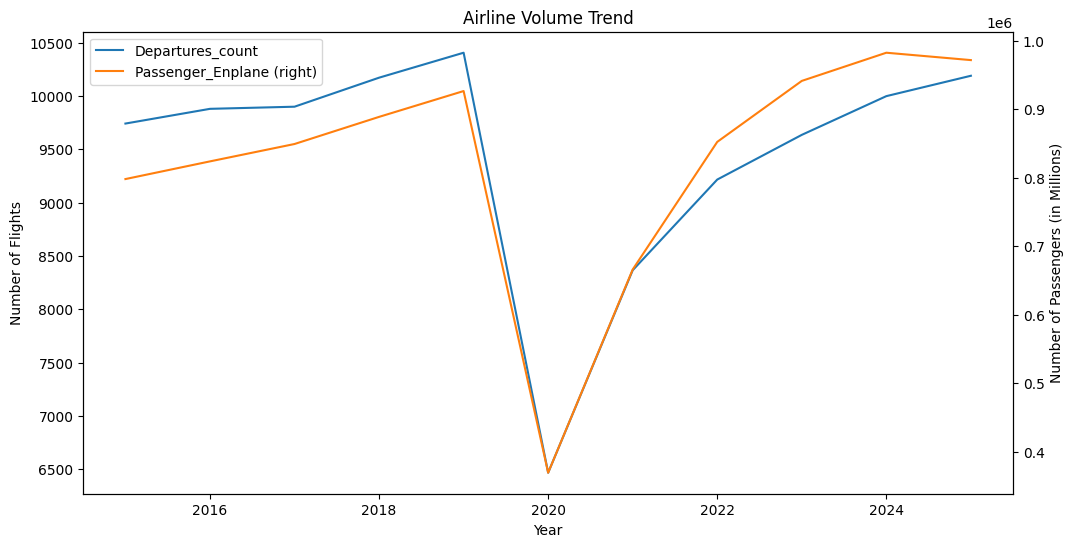

In [17]:
#plt.figure(figsize=(14,6))

ax = fvolume.plot(x='Year', y='Departures_count',  ylabel='Number of Flights', figsize=(12,6))
ax.set_title('Airline Volume Trend')

fvolume.plot(
    x='Year',
    y='Passenger_Enplane',
    ylabel='Number of Passengers (in Millions)',
    ax=ax,
    secondary_y=True
)

plt.show()

In [18]:
fig = px.line(fvolume, x='Year', y='Departures_count')
fig.show()

In [19]:
px.line(fvolume, x='Year', y='Passenger_Enplane')

In [20]:
print(fvolume[['Year', 'Departures_count']].head(10))
print(fvolume[['Year', 'Departures_count']].dtypes)

   Year  Departures_count
0  2025             10189
1  2024              9998
2  2023              9635
3  2022              9216
4  2021              8366
5  2020              6468
6  2019             10405
7  2018             10171
8  2017              9899
9  2016              9879
Year                int64
Departures_count    int64
dtype: object


In [21]:
fig = go.Figure()

# First line (left y-axis)
fig.add_trace(go.Scatter(
    x=fvolume['Year'],
    y=fvolume['Departures_count'],
    name='Flights',
    mode='lines'
))

# Second line (right y-axis)
fig.add_trace(go.Scatter(
    x=fvolume['Year'],
    y=fvolume['Passenger_Enplane'],
    name='Passengers',
    mode='lines',
    yaxis='y2'
))

# Layout (this replaces plt + labels + title)
fig.update_layout(
    title='Airline Volume Trend (Number of Flights vs Number of Passengers)',
    xaxis=dict(title='Year'),
    yaxis=dict(title='Number of Flights'),
    yaxis2=dict(
        title='Number of Passengers (in Millions)',
        overlaying='y',
        side='right'
    ),
    width=800,
    height=600,
    template='plotly_white'
)

fig.show()

In [22]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fvolume['Departures_count'],
    y=fvolume['Passenger_Enplane'],
    mode='markers',   # key change
    name='Flights vs Passengers'
))

fig.update_layout(
    title='Correlation: Flights vs Passengers',
    xaxis_title='Number of Flights',
    yaxis_title='Number of Passengers',
    width=800,
    height=600,
    template='plotly_white'
)

fig.show()

In [24]:
fig = px.scatter(
    fvolume,
    x='Departures_count',
    y='Passenger_Enplane'
)
fig.show()

In [25]:
fig = px.scatter(
    fvolume,
    x='Departures_count',
    y='Passenger_Enplane',
    trendline='ols'   # adds regression line
)

fig.show()

In [34]:
fig = px.scatter(
    fvolume_3,
    x='Departures_count',
    y='Passenger_Enplane',
    trendline='ols'   # adds regression line
)

fig.show()

In [37]:
fig = px.scatter(
    fvolume_1,
    x='Departures_count',
    y='Passenger_Enplane',
    trendline='ols'   # adds regression line
)

fig.show()

In [42]:
fig = px.scatter(
    fvolume_2,
    x='Departures_count',
    y='Passenger_Enplane',
    trendline='ols'   # adds regression line
)

fig.show()

In [26]:
corr = fvolume['Departures_count'].corr(fvolume['Passenger_Enplane'])
print(corr)

0.9443992944669083


In [38]:
corr3 = fvolume_3['Departures_count'].corr(fvolume_3['Passenger_Enplane'])
print(corr3)

0.9371605152409623


In [39]:
corr1 = fvolume_1['Departures_count'].corr(fvolume_1['Passenger_Enplane'])
print(corr1)

0.9688638272916574


In [43]:
corr2 = fvolume_2['Departures_count'].corr(fvolume_2['Passenger_Enplane'])
print(corr2)


0.9983114979248223
